In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4


In [ ]:
import pandas as pd

df = pd.read_csv('/root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4/Tweets.csv')
df.head(10)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


In [ ]:
unique_sentiments = df['airline_sentiment'].unique()

print("5 Sample Tweets for each Airline Sentiment:\n")

for sentiment in unique_sentiments:
    print(f"--- Sentiment: {sentiment.capitalize()} ---")
    sample_tweets = df[df['airline_sentiment'] == sentiment]['text'].sample(n=5, random_state=42)
    for i, tweet in enumerate(sample_tweets):
        print(f"{i+1}. {tweet}")
    print("\n")

5 Sample Tweets for each Airline Sentiment:

--- Sentiment: Neutral ---
1. @united we finally just arrive to Bogota, good but long flight!!
2. @AmericanAir got a callback at 1 am, took care of it. thanks.
3. @JetBlue is there wifi on he plain
4. @JetBlue @BucketObolts Same
5. @SouthwestAir how many are left?!


--- Sentiment: Positive ---
1. @SouthwestAir thanks for your excellent response time and assistance! All set :)
2. @JetBlue thanks. I appreciate your prompt response.
3. @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!
4. @USAirways YOU ARE THE BEST!!! FOLLOW ME PLEASE;)🙏🙏🙏✌️✌️✌️🙏🙏🙏
5. @JetBlue beautiful ride. Thanks again:)


--- Sentiment: Negative ---
1. @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi
2. @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.

In [ ]:
df['tweet_length'] = df['text'].str.len()
print("Added 'tweet_length' column. First 5 tweet lengths:")
print(df['tweet_length'].head())

Added 'tweet_length' column. First 5 tweet lengths:
0     35
1     72
2     71
3    126
4     55
Name: tweet_length, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Imported matplotlib.pyplot as plt and seaborn as sns.")

Imported matplotlib.pyplot as plt and seaborn as sns.


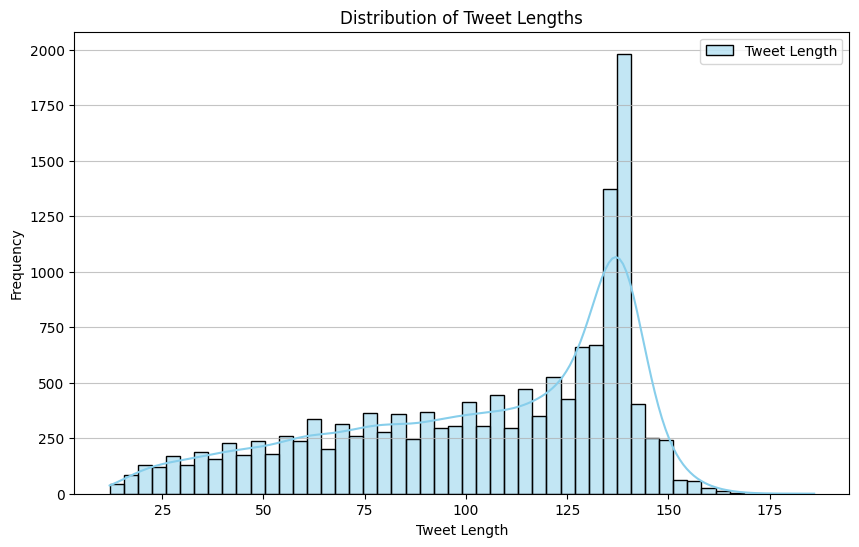

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['tweet_length'], bins=50, kde=True, color='skyblue', label='Tweet Length')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import re

def extract_hashtags(text):
    hashtags = re.findall(r"#\w+", text)
    return hashtags

print("Function 'extract_hashtags' defined.")

Function 'extract_hashtags' defined.


In [ ]:
def extract_mentions(text):
    mentions = re.findall(r"@\w+", text)
    return mentions

print("Function 'extract_mentions' defined.")

Function 'extract_mentions' defined.


In [ ]:
def extract_urls(text):
    urls = re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)
    return urls

print("Function 'extract_urls' defined.")

Function 'extract_urls' defined.


In [ ]:
df['mentions'] = df['text'].apply(extract_mentions)
total_mentions = sum(df['mentions'].apply(len))

print(f"Total mentions found: {total_mentions}")

Total mentions found: 16507


In [ ]:
df['hashtags'] = df['text'].apply(extract_hashtags)
total_hashtags = sum(df['hashtags'].apply(len))

print(f"Total hashtags found: {total_hashtags}")

Total hashtags found: 3502


In [ ]:
df['urls'] = df['text'].apply(extract_urls)
total_urls = sum(df['urls'].apply(len))

print(f"Total URLs found: {total_urls}")

Total URLs found: 1211


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('maxent_ne_chunker_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk import FreqDist
from nltk.stem import WordNetLemmatizer
from collections import Counter
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


# Tokenization

In [ ]:
def word_tokenizer(text):
  tokenize = word_tokenize(text)
  return tokenize

In [ ]:
def sent_tokenizer(text):
  tokenize = word_tokenize(text)
  return tokenize

In [ ]:
def t_tokenizer(text):
  tokenizer = TweetTokenizer()
  token = tokenizer.tokenize(text)
  return tokenizer

# StopWord

In [ ]:
def word_stopword(text):
  stop_words = set(stopwords.words('english'))
  word_tokens = word_tokenize(text)
  filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
  return filtered_sentence

# Stemming vs Lemmatization

In [ ]:
stemmer = PorterStemmer()

def word_stemmer(text):
  word_tokens = word_tokenize(text)
  stems = [stemmer.stem(word) for word in word_tokens]
  return stems

In [ ]:
stemmer = SnowballStemmer(language='english')

def word_stemmer(text):
  word_tokens = word_tokenize(text)
  stems = [stemmer.stem(word) for word in word_tokens]
  return stems

In [ ]:
lemmatizer = WordNetLemmatizer()

def word_lemmatizer(text):
  word_tokens = word_tokenize(text)
  lemmas = [lemmatizer.lemmatize(word) for word in word_tokens]
  return lemmas

In [ ]:
def NLTK_Prepocessing(text):

  # Tokenization
  tokenized_words_result = word_tokenizer(text)
  print("\nWord Tokenization:", tokenized_words_result)

  tokenized_sentences_result = sent_tokenizer(text)
  print("\nSentence Tokenization (using word_tokenizer logic):", tokenized_sentences_result)

  tweet_tokenizer_obj = t_tokenizer(text)
  tweet_tokens_result = tweet_tokenizer_obj.tokenize(text)
  print("\nTweet Tokenization:", tweet_tokens_result)


  sample_text_for_ops = " ".join(['running', 'runs', 'ran'])

  # Stopword removal
  filtered_words_result = word_stopword(sample_text_for_ops)
  print("\nStopword Removal (on sample text):", filtered_words_result)

  # Stemming
  stemmed_words_result = word_stemmer(sample_text_for_ops)
  print("\nStemming (on sample text):", stemmed_words_result)

  # Lemmatization
  lemmatized_words_result = word_lemmatizer(sample_text_for_ops)
  print("\nLemmatization (on sample text):", lemmatized_words_result)

  # POS Tagging (using the tokenized_words_result from the input 'text')
  pos_tags_result = nltk.pos_tag(tokenized_words_result)
  print("\nPOS Tagging (on input text tokens):", pos_tags_result)

  # Frequency Distribution
  freq = FreqDist(tokenized_words_result)
  filtered_freq_words_result = [word for word, count in freq.items() if count > 1]
  print("\nWords with frequency > 1 (from input text):", filtered_freq_words_result)

# Spacy

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
def spacy_prepocessing(text):

  doc = nlp(text)
  print('\n tikens:')
  for token in doc:
    print(token.text)

  print('\n'f'{'token':<15}{'POS':<10}{'Detailed Tag':<15}{'Explaination'}')
  print(f'{"-"*15}{"-"*10}{"-"*15}{"-"*15}')
  for token in doc:
    print(f'{token.text:<15}{token.pos_:<10}{token.tag_:<15}{spacy.explain(token.tag_)}')

  print('\n'f'{'token':<25}{'Head':<25}{'dep':<15}{'POS':<10}{'Explaination'}')
  print(f'{"-"*25}{"-"*25}{"-"*15}{"-"*10}{"-"*15}')
  for token in doc:
    print(f'{token.text:<25}{token.head.text:<25}{token.dep_:<15}{token.pos_:<10}{spacy.explain(token.tag_)}')

  print('\n'f'{'token':<25}{'Head':<25}{'dep':<15}{'POS':<10}{'Explaination'}')
  print(f'{"-"*25}{"-"*25}{"-"*15}{"-"*10}{"-"*15}')
  for chunk in doc.noun_chunks:
    print(f'{chunk.text:<25}{chunk.root.text:<25}{chunk.root.dep_:<15}{chunk.root.pos_:<10}{spacy.explain(chunk.root.tag_)}')

  print('\n'f'{'Entity text':<25}{'Entity label':<25}{'Entity type':<15}{'Explaination'}')
  print(f'{"-"*25}{"-"*25}{"-"*15}{"-"*15}')
  for ent in doc.ents:
    print(f'{ent.text:<25}{ent.label_:<25}{ent.ent_type_:<15}{spacy.explain(ent.ent_type_)}')

In [ ]:
if __name__ == '__main__':
  ds = df['text']

  ## using POS
  print('USING POS')
  NLTK_Prepocessing(ds[1])

  ## spacy
  print('\n USING SPACY')
  spacy_prepocessing(ds[9])

  nlp = spacy.load('en_core_web_sm')
  doc_1 = nlp(ds[9])
  doc_2 = nlp(ds[9])
  similarity = doc_1.similarity(doc_2)
  print(f'Similarity Score: {similarity}')

USING POS

Word Tokenization: ['@', 'VirginAmerica', 'plus', 'you', "'ve", 'added', 'commercials', 'to', 'the', 'experience', '...', 'tacky', '.']

Sentence Tokenization (using word_tokenizer logic): ['@', 'VirginAmerica', 'plus', 'you', "'ve", 'added', 'commercials', 'to', 'the', 'experience', '...', 'tacky', '.']

Tweet Tokenization: ['@VirginAmerica', 'plus', "you've", 'added', 'commercials', 'to', 'the', 'experience', '...', 'tacky', '.']

Stopword Removal (on sample text): ['running', 'runs', 'ran']

Stemming (on sample text): ['run', 'run', 'ran']

Lemmatization (on sample text): ['running', 'run', 'ran']

POS Tagging (on input text tokens): [('@', 'NN'), ('VirginAmerica', 'NNP'), ('plus', 'CC'), ('you', 'PRP'), ("'ve", 'VBP'), ('added', 'VBN'), ('commercials', 'NNS'), ('to', 'TO'), ('the', 'DT'), ('experience', 'NN'), ('...', ':'), ('tacky', 'NN'), ('.', '.')]

Words with frequency > 1 (from input text): []

 USING SPACY

 tikens:
@VirginAmerica
it
was
amazing
,
and
arrived
an
h

## Use Case Recommendations: NLTK vs. spaCy vs. Hybrid Approach

Choosing between NLTK and spaCy (or a combination) depends heavily on the specific NLP task, performance requirements, and the scale of the project. Here's a decision matrix to guide your choice:

### 1. When to use NLTK?

**NLTK (Natural Language Toolkit)** is often preferred for:

*   **Academic Research & Education**: Its comprehensive suite of algorithms, linguistic corpora, and diverse implementations make it excellent for exploring various NLP techniques, learning concepts, and conducting research.
*   **Flexibility & Customization**: If you need fine-grained control over each step of the NLP pipeline (e.g., trying different tokenizers, stemmers, or taggers), NLTK's modular structure allows for easy experimentation and customization.
*   **Broad Linguistic Coverage**: NLTK provides access to a wide range of linguistic data (corpora, lexicons) and algorithms for tasks like sentiment analysis, topic modeling, and language identification.
*   **Prototyping & Experimentation**: For initial explorations or when you're not constrained by strict performance requirements, NLTK offers a quick way to prototype ideas and test different approaches.
*   **Symbolic and Statistical NLP Integration**: It integrates both symbolic (rule-based) and statistical approaches well.

**Examples:**
*   Building a custom part-of-speech tagger for a niche language.
*   Conducting sentiment analysis using lexicon-based methods.
*   Text classification with various feature extraction techniques.
*   Educational projects demonstrating core NLP algorithms.

### 2. When to use spaCy?

**spaCy** excels in production environments and when performance is critical:

*   **Production-Ready Applications**: Designed for speed, efficiency, and robustness, spaCy is ideal for deploying NLP models in real-world applications.
*   **High Performance & Scalability**: It's built with CPython and Cython, making it significantly faster for common NLP tasks like tokenization, POS tagging, NER, and dependency parsing.
*   **Pre-trained Statistical Models**: spaCy comes with highly optimized, pre-trained models for various languages, allowing for out-of-the-box performance without extensive training.
*   **Named Entity Recognition (NER)**: Its state-of-the-art NER capabilities are particularly strong, making it a go-to for extracting entities like names, organizations, dates, etc.
*   **Deep Learning Integration**: It integrates well with deep learning frameworks like TensorFlow and PyTorch for custom model training.
*   **Rule-based Matching**: Offers powerful and efficient rule-based matching for identifying patterns in text.

**Examples:**
*   Building a chatbot that needs to quickly understand user intent and extract entities.
*   Developing a document classification system for large volumes of text.
*   Creating an information extraction pipeline for legal or medical documents.
*   Real-time text processing in dashboards or monitoring tools.

### 3. Hybrid Approach Scenarios

Sometimes, combining the strengths of both libraries offers the best solution:

*   **Deep Customization + Production Performance**: Use NLTK for specialized, custom preprocessing steps (e.g., advanced tokenization or stemming specific to a domain) or for tasks where spaCy doesn't offer a direct solution. Then, feed the preprocessed text into spaCy for its robust and fast core NLP functionalities like NER, dependency parsing, or custom text classification with spaCy's TextCategorizer.
*   **Leveraging NLTK's Resources with spaCy's Efficiency**: Use NLTK for its vast collection of corpora and lexical resources (like WordNet) for linguistic analysis, and spaCy for tokenization, POS tagging, and other pipeline components due to its speed.
*   **Educational Exploration with Production Deployment**: For learning purposes, use NLTK to understand the underlying algorithms. Once a method is chosen, if performance is critical for deployment, re-implement or adapt the approach using spaCy's optimized components.
*   **Complex Text Generation/Summarization**: NLTK's advanced text generation capabilities might be combined with spaCy's robust parsing for initial understanding and structural analysis of text.

**Examples:**
*   Performing advanced grammatical analysis using NLTK's parser, then using spaCy to extract named entities and relationships from the parsed output.
*   Using NLTK for specialized sentiment lexicon development, and then integrating this into a spaCy pipeline for real-time sentiment scoring on incoming messages.
*   Initial data cleaning and normalization using NLTK, followed by spaCy for building and deploying a machine learning model.

In [ ]:
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

print("Helper function 'get_wordnet_pos' defined.")

Helper function 'get_wordnet_pos' defined.


In [ ]:
import spacy
import re

# Load the spaCy model (already loaded in previous step, but good practice)
# nlp = spacy.load('en_core_web_sm') # Assuming 'nlp' is already loaded from cell nXAmcEXqdNlP

def preprocess_spacy(text):
    # 1. Remove URLs
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*()]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # 2. Remove mentions
    text = re.sub(r'@\w+', '', text)

    # 3. Process text with spaCy
    doc = nlp(text)

    # 4. Lemmatize and filter tokens
    processed_tokens = []
    for token in doc:
        # Filter out stopwords, punctuation, purely numeric tokens, and whitespace
        if not token.is_stop and not token.is_punct and not token.is_digit and not token.is_space:
            processed_tokens.append(token.lemma_.lower())

    return processed_tokens

print("spaCy preprocessing function 'preprocess_spacy' defined.")

spaCy preprocessing function 'preprocess_spacy' defined.


In [ ]:
sample_tweets_df = df['text'].sample(n=10000, random_state=42).reset_index(drop=True).copy()
print(f"Sampled {len(sample_tweets_df)} tweets for analysis.")
print("First 5 sampled tweets:")
print(sample_tweets_df.head())

Sampled 10000 tweets for analysis.
First 5 sampled tweets:
0    @SouthwestAir you're my early frontrunner for ...
1    @USAirways how is it that my flt to EWR was Ca...
2    @JetBlue what is going on with your BDL to DCA...
3    @JetBlue do they have to depart from Washingto...
4    @JetBlue I can probably find some of them. Are...
Name: text, dtype: object


In [ ]:
import time

nltk_processed_tokens_list = []
nltk_start_time = time.time()

for tweet in sample_tweets_df:
    nltk_processed_tokens_list.append(preprocess_nltk(tweet))

nltk_end_time = time.time()
nltk_processing_time = nltk_end_time - nltk_start_time

print(f"NLTK processing time: {nltk_processing_time:.2f} seconds")

NLTK processing time: 11.02 seconds


In [ ]:
spacy_processed_tokens_list = []
spacy_start_time = time.time()

for tweet in sample_tweets_df:
    spacy_processed_tokens_list.append(preprocess_spacy(tweet))

spacy_end_time = time.time()
spacy_processing_time = spacy_end_time - spacy_start_time

print(f"spaCy processing time: {spacy_processing_time:.2f} seconds")

spaCy processing time: 96.56 seconds


In [ ]:
nltk_total_tokens = sum(len(tweet_tokens) for tweet_tokens in nltk_processed_tokens_list)
nltk_avg_tokens_per_tweet = nltk_total_tokens / len(sample_tweets_df)
all_nltk_tokens = [token for tweet_tokens in nltk_processed_tokens_list for token in tweet_tokens]
nltk_unique_tokens = len(set(all_nltk_tokens))

spacy_total_tokens = sum(len(tweet_tokens) for tweet_tokens in spacy_processed_tokens_list)
spacy_avg_tokens_per_tweet = spacy_total_tokens / len(sample_tweets_df)
all_spacy_tokens = [token for tweet_tokens in spacy_processed_tokens_list for token in tweet_tokens]
spacy_unique_tokens = len(set(all_spacy_tokens))

print(f"NLTK Total Tokens: {nltk_total_tokens}")
print(f"NLTK Average Tokens per Tweet: {nltk_avg_tokens_per_tweet:.2f}")
print(f"NLTK Unique Tokens (Vocabulary Size): {nltk_unique_tokens}")
print(f"\nspaCy Total Tokens: {spacy_total_tokens}")
print(f"spaCy Average Tokens per Tweet: {spacy_avg_tokens_per_tweet:.2f}")
print(f"spaCy Unique Tokens (Vocabulary Size): {spacy_unique_tokens}")

NLTK Total Tokens: 84169
NLTK Average Tokens per Tweet: 8.42
NLTK Unique Tokens (Vocabulary Size): 7436

spaCy Total Tokens: 78069
spaCy Average Tokens per Tweet: 7.81
spaCy Unique Tokens (Vocabulary Size): 8952


In [ ]:
import pandas as pd

metrics_data = {
    'Metric': ['Processing Time (seconds)', 'Average Tokens per Tweet', 'Unique Tokens (Vocabulary Size)'],
    'NLTK': [nltk_processing_time, nltk_avg_tokens_per_tweet, nltk_unique_tokens],
    'spaCy': [spacy_processing_time, spacy_avg_tokens_per_tweet, spacy_unique_tokens]
}

comparison_df = pd.DataFrame(metrics_data)
print("Comparison of NLTK and spaCy Preprocessing Metrics:")
print(comparison_df.to_markdown(index=False))

Comparison of NLTK and spaCy Preprocessing Metrics:
| Metric                          |      NLTK |     spaCy |
|:--------------------------------|----------:|----------:|
| Processing Time (seconds)       |   11.0236 |   96.5648 |
| Average Tokens per Tweet        |    8.4169 |    7.8069 |
| Unique Tokens (Vocabulary Size) | 7436      | 8952      |


/tmp/ipython-input-3433904369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['NLTK', 'spaCy'], y=[nltk_processing_time, spacy_processing_time], palette='viridis')


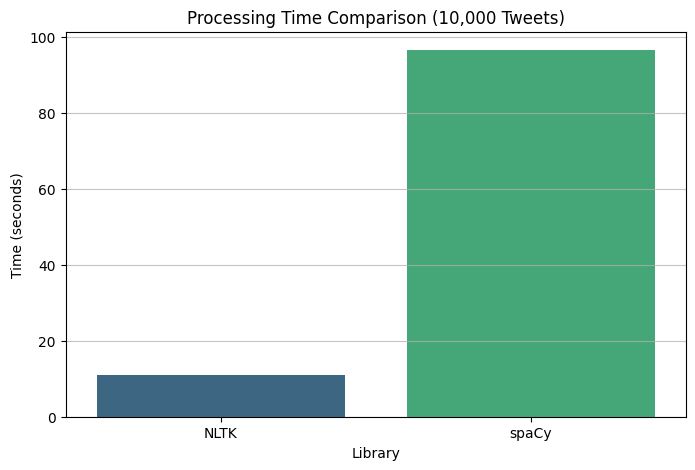

Bar chart showing processing times has been displayed.


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=['NLTK', 'spaCy'], y=[nltk_processing_time, spacy_processing_time], palette='viridis')
plt.title('Processing Time Comparison (10,000 Tweets)')
plt.xlabel('Library')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("Bar chart showing processing times has been displayed.")

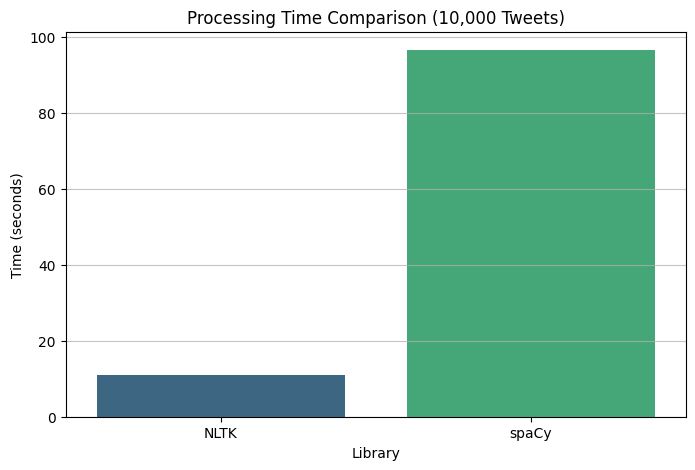

Bar chart showing processing times has been displayed.


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=['NLTK', 'spaCy'], y=[nltk_processing_time, spacy_processing_time], hue=['NLTK', 'spaCy'], palette='viridis', legend=False)
plt.title('Processing Time Comparison (10,000 Tweets)')
plt.xlabel('Library')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("Bar chart showing processing times has been displayed.")

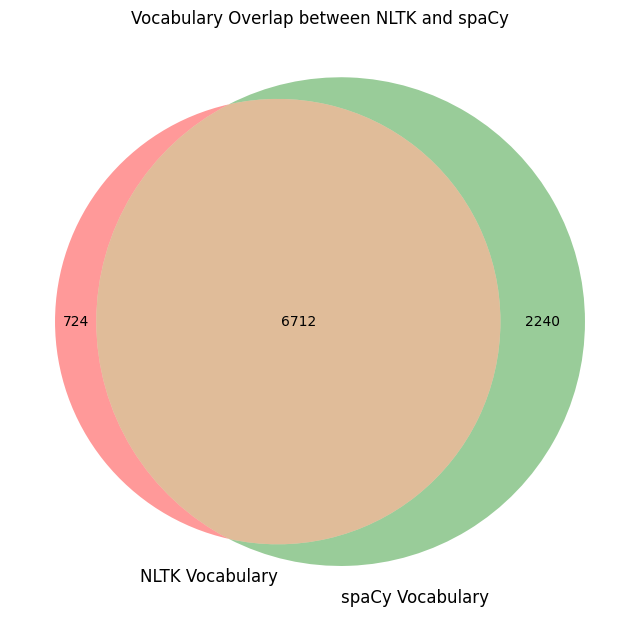

Venn diagram showing vocabulary overlap has been displayed.


In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

nltk_vocab = set(all_nltk_tokens)
spacy_vocab = set(all_spacy_tokens)

plt.figure(figsize=(8, 8))
venn2([nltk_vocab, spacy_vocab], ('NLTK Vocabulary', 'spaCy Vocabulary'))
plt.title('Vocabulary Overlap between NLTK and spaCy')
plt.show()
print("Venn diagram showing vocabulary overlap has been displayed.")

**Reasoning**:
I will calculate the token counts per tweet for both NLTK and spaCy by getting the length of each list of processed tokens for each tweet.



In [ ]:
nltk_token_counts = [len(tokens) for tokens in nltk_processed_tokens_list]
spacy_token_counts = [len(tokens) for tokens in spacy_processed_tokens_list]

print(f"NLTK token counts for first 5 tweets: {nltk_token_counts[:5]}")
print(f"spaCy token counts for first 5 tweets: {spacy_token_counts[:5]}")

NLTK token counts for first 5 tweets: [4, 10, 11, 2, 3]
spaCy token counts for first 5 tweets: [5, 8, 9, 3, 4]


**Reasoning**:
I will create two histograms to visualize the distribution of token counts per tweet for both NLTK and spaCy, as specified in the task instructions.



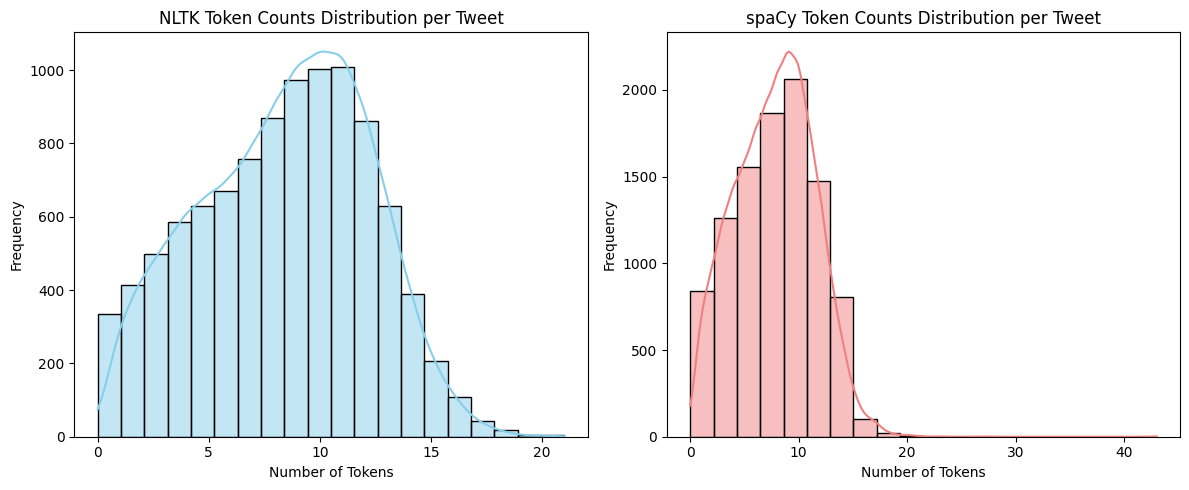

Histograms showing token count distributions for NLTK and spaCy have been displayed.


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(nltk_token_counts, bins=20, kde=True, color='skyblue')
plt.title('NLTK Token Counts Distribution per Tweet')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(spacy_token_counts, bins=20, kde=True, color='lightcoral')
plt.title('spaCy Token Counts Distribution per Tweet')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Histograms showing token count distributions for NLTK and spaCy have been displayed.")